In [1]:
import os, sys
os.environ["PYTHONNOUSERSITE"] = "1"
sys.path = [p for p in sys.path if ".local" not in p]

In [4]:
def evaluate_model(model, test_dataloader):
    model.eval()
    all_mae = []
    all_mae_low = []
    all_mae_high = []

    all_output = []
    all_output_low = []
    all_output_high = []

    all_true = []
    all_true_low = []
    all_true_high = []
    all_attention_weights = []
    all_output_all = []
    all_true_all = []

    with torch.no_grad():
        for data in tqdm(test_dataloader, desc="Evaluating"):
            data = data.to(device)
            output, attention = model.forward(
                data.X, data.structure_feat, data.seq_feat,
                data.edge_index, data.batch
            )
            # print('get att!!!',attention)
            is_range_mask = (data.ph_max - data.ph_min) >= 1
            not_range_mask = (data.ph_max - data.ph_min) < 1

            all_attention_weights.append(attention)

            all_output_all.append(output.cpu())  # shape [B, 2]
            all_true_all.append(torch.stack([data.ph_min, data.ph_max], dim=1).cpu())  # shape [B, 2]

            mae = ((data.ph_min + data.ph_max) / 2) - output.mean(axis=1)
            mae_low = (data.ph_min - output[:, 0]).abs()[is_range_mask]
            mae_high = (data.ph_max - output[:, 1]).abs()[is_range_mask]

            all_mae.append(mae.abs()[not_range_mask])
            all_mae_low.append(mae_low)
            all_mae_high.append(mae_high)

            all_output.append(output.mean(axis=1)[not_range_mask])
            all_output_low.append(output[:, 0][is_range_mask])
            all_output_high.append(output[:, 1][is_range_mask])

            all_true.append((data.ph_min + data.ph_max)[not_range_mask] / 2)
            all_true_low.append(data.ph_min[is_range_mask])
            all_true_high.append(data.ph_max[is_range_mask])
    
    return all_attention_weights


In [12]:

import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm
import os, random, pickle
from torch_geometric.loader import DataLoader
from scipy.stats import pearsonr
from data_split import *
import egnn_model_split_range 
from egnn_model_split_range import DeeppH

egnn_model_split_range.GraphEC_pH = DeeppH 
device = "cuda:6"
config = {
    'node_input_dim': 1024 + 9 + 184,
    'edge_input_dim': 450,
    'hidden_dim': 128,
    'layer': 1,
    'augment_eps': 0.15,
    'dropout': 0.1,
    'task':'pH',
    'batch_size': 16,
    'folds': 5,
    'r':15,
    'num_workers':8,
}

node_input_dim = config['node_input_dim']
edge_input_dim = config['edge_input_dim']
hidden_dim = config['hidden_dim']
layer = config['layer']
augment_eps = config['augment_eps']
dropout = config['dropout']
num_workers = config['num_workers']
folds = config['folds']
r = config['r']
task = config['task']

def evaluate_model(model, test_dataloader):
    model.eval()
    all_mae = []
    all_mae_low = []
    all_mae_high = []

    all_output = []
    all_output_low = []
    all_output_high = []

    all_true = []
    all_true_low = []
    all_true_high = []
    all_attention_weights = []

    all_output_all = []
    all_true_all = []

    with torch.no_grad():
        for data in tqdm(test_dataloader, desc="Evaluating"):
            data = data.to(device)
            output, attention = model.forward(
                data.X, data.structure_feat, data.seq_feat,
                data.edge_index, data.batch
            )
            # print('get att!!!',attention)
            is_range_mask = (data.ph_max - data.ph_min) >= 1
            not_range_mask = (data.ph_max - data.ph_min) < 1

            all_attention_weights.append(attention)
            all_output_all.append(output.cpu())  # shape [B, 2]
            all_true_all.append(torch.stack([data.ph_min, data.ph_max], dim=1).cpu())  # shape [B, 2]

    
            mae = ((data.ph_min + data.ph_max) / 2) - output.mean(axis=1)
            mae_low = (data.ph_min - output[:, 0]).abs()[is_range_mask]
            mae_high = (data.ph_max - output[:, 1]).abs()[is_range_mask]

            all_mae.append(mae.abs()[not_range_mask])
            all_mae_low.append(mae_low)
            all_mae_high.append(mae_high)

            all_output.append(output.mean(axis=1)[not_range_mask])
            all_output_low.append(output[:, 0][is_range_mask])
            all_output_high.append(output[:, 1][is_range_mask])

            all_true.append((data.ph_min + data.ph_max)[not_range_mask] / 2)
            all_true_low.append(data.ph_min[is_range_mask])
            all_true_high.append(data.ph_max[is_range_mask])
    
    return all_attention_weights

# att = evaluate_model(model, test_dataloader)


print("Loading Testing Set")
with open("/home/wang3wa/EC_prediction/mine/deepPH/train/new_test_value.pkl", "rb") as f:
    all_data = pickle.load(f)
# test_data = [item for item in all_data if item.get('id', '') == "Q97VS7"]
test_data = all_data
test_dataset = ProteinPHValueGraphDataset(test_data, radius=r)
test_dataloader = DataLoader(test_dataset, batch_size = 32, shuffle=False, drop_last=False, num_workers=num_workers, prefetch_factor=2)

model_dir = "/home/wang3wa/EC_prediction/mine/deepPH/model/"
model_files = [f for f in os.listdir(model_dir) if f.endswith("20250507.pt")] #test_model_r2_split_aa_range_20250507.pt

mae_list = []
rmse_list = []

for model_file in model_files:
    print(f"\nLoading model: {model_file}")
    model_path = os.path.join(model_dir, model_file)
    
    loaded = torch.load(model_path, weights_only=False)
    
    if isinstance(loaded, dict):
        model = DeeppH(node_input_dim, edge_input_dim, hidden_dim, layer, dropout, augment_eps, task, device).to(device)
        model.load_state_dict(loaded)
    else:
        
        model = loaded.to(device)
att = evaluate_model(model,test_dataloader)


Loading Testing Set

Loading model: test_model_r2_split_aa_range_20250507.pt


Evaluating: 100%|██████████| 26/26 [00:04<00:00,  5.49it/s]


In [18]:
TOP_PERCENTILE    = 90   # top 10% attention -> high attention residues
BOTTOM_PERCENTILE = 10   # bottom 10%        -> low attention residues

# Collect high/low attention residue f_geo vectors
high_att_fgeo = []
low_att_fgeo  = []
all_att        = all_protein_att
for fgeo, att_vec in zip(all_fgeo, all_att):
    threshold_high = np.percentile(att_vec, TOP_PERCENTILE)
    threshold_low  = np.percentile(att_vec, BOTTOM_PERCENTILE)

    high_mask = att_vec >= threshold_high
    low_mask  = att_vec <= threshold_low

    high_att_fgeo.append(fgeo[high_mask])
    low_att_fgeo.append(fgeo[low_mask])

high_att_fgeo = np.vstack(high_att_fgeo)  # [N_high, 184]
low_att_fgeo  = np.vstack(low_att_fgeo)   # [N_low,  184]

print(f"High attention residues: {len(high_att_fgeo)}")
print(f"Low  attention residues: {len(low_att_fgeo)}")

# ============================================================
# Compute mean difference per dimension
# ============================================================
mean_high = high_att_fgeo.mean(axis=0)  # [184]
mean_low  = low_att_fgeo.mean(axis=0)   # [184]
diff       = mean_high - mean_low        # [184]

# Subcomponent indices
idx = {
    'Dihedral\n(0:6)'     : (0,   6),
    'Bond Angle\n(6:12)'  : (6,   12),
    'Node Dist\n(12:172)' : (12,  172),
    'Direction\n(172:184)': (172, 184),
}

High attention residues: 41757
Low  attention residues: 41757


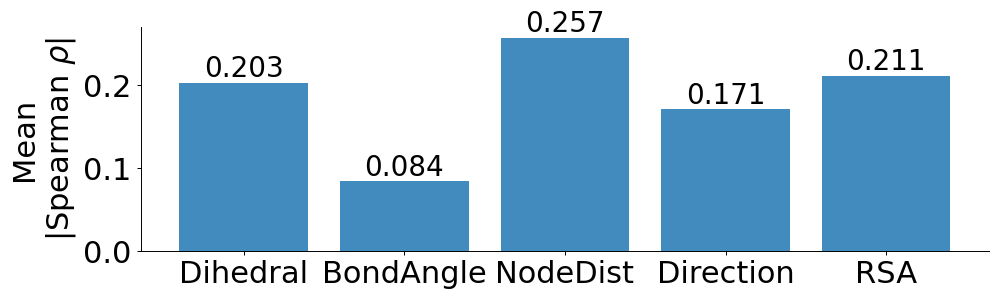

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from scipy.stats import spearmanr

# =========================
# Font settings
# =========================
LABEL_SIZE = 22
TICK_SIZE = 22
VALUE_SIZE = 20


def clean_name(name):
    name = name.replace("\n", "")
    name = name.replace(" ", "")
    name = re.sub(r"\s*\(.*?\)", "", name)
    return name.strip()


def compute_rsa_augmented_features(test_dataset, all_fgeo, idx):

    all_rsa = []
    for data_obj in test_dataset:
        all_rsa.append(data_obj.structure_feat[:, 12].cpu().numpy())

    all_fgeo_rsa = []
    for fgeo, rsa in zip(all_fgeo, all_rsa):
        rsa = rsa.reshape(-1, 1)
        all_fgeo_rsa.append(np.concatenate([fgeo, rsa], axis=1))

    idx_rsa = dict(idx)
    idx_rsa["RSA"] = (184, 185)
    return all_fgeo_rsa, idx_rsa


def compute_spearman_correlation(all_fgeo_use, all_att):

    all_fgeo_flat = np.vstack(all_fgeo_use)      # [N_residue, 185]
    all_att_flat = np.concatenate(all_att)        # [N_residue]

    n_dims = all_fgeo_flat.shape[1]
    corr = np.zeros(n_dims)
    pvals = np.zeros(n_dims)

    for d in range(n_dims):
        if np.std(all_fgeo_flat[:, d]) < 1e-8:
            corr[d] = np.nan
            pvals[d] = np.nan
            continue
        r, p = spearmanr(all_fgeo_flat[:, d], all_att_flat)
        corr[d] = r
        pvals[d] = p

    return corr, pvals


def plot_subcomponent_attention_correlation(idx_rsa, corr, save_path=None):

    names = list(idx_rsa.keys())
    values = [np.nanmean(np.abs(corr[s:e])) for _, (s, e) in idx_rsa.items()]
    clean_names = [clean_name(n) for n in names]

    plt.figure(figsize=(10, 3))
    bars = plt.bar(range(len(clean_names)), values, alpha=0.85)

    plt.xticks(range(len(clean_names)), clean_names, fontsize=TICK_SIZE)
    plt.ylabel("Mean\n|Spearman $\\rho$|", fontsize=LABEL_SIZE)
    plt.yticks(fontsize=TICK_SIZE)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            val,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=VALUE_SIZE
        )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()



all_fgeo_use, idx_rsa = compute_rsa_augmented_features(test_dataset, all_fgeo, idx)
corr, pvals = compute_spearman_correlation(all_fgeo_use, all_att)
plot_subcomponent_attention_correlation(
    idx_rsa, corr
)

Extracting f_geo...


100%|██████████| 803/803 [00:15<00:00, 50.57it/s]


f_geo dims: 184 (SASA analyzed separately)
High attention residues: 41757
Low  attention residues: 41757


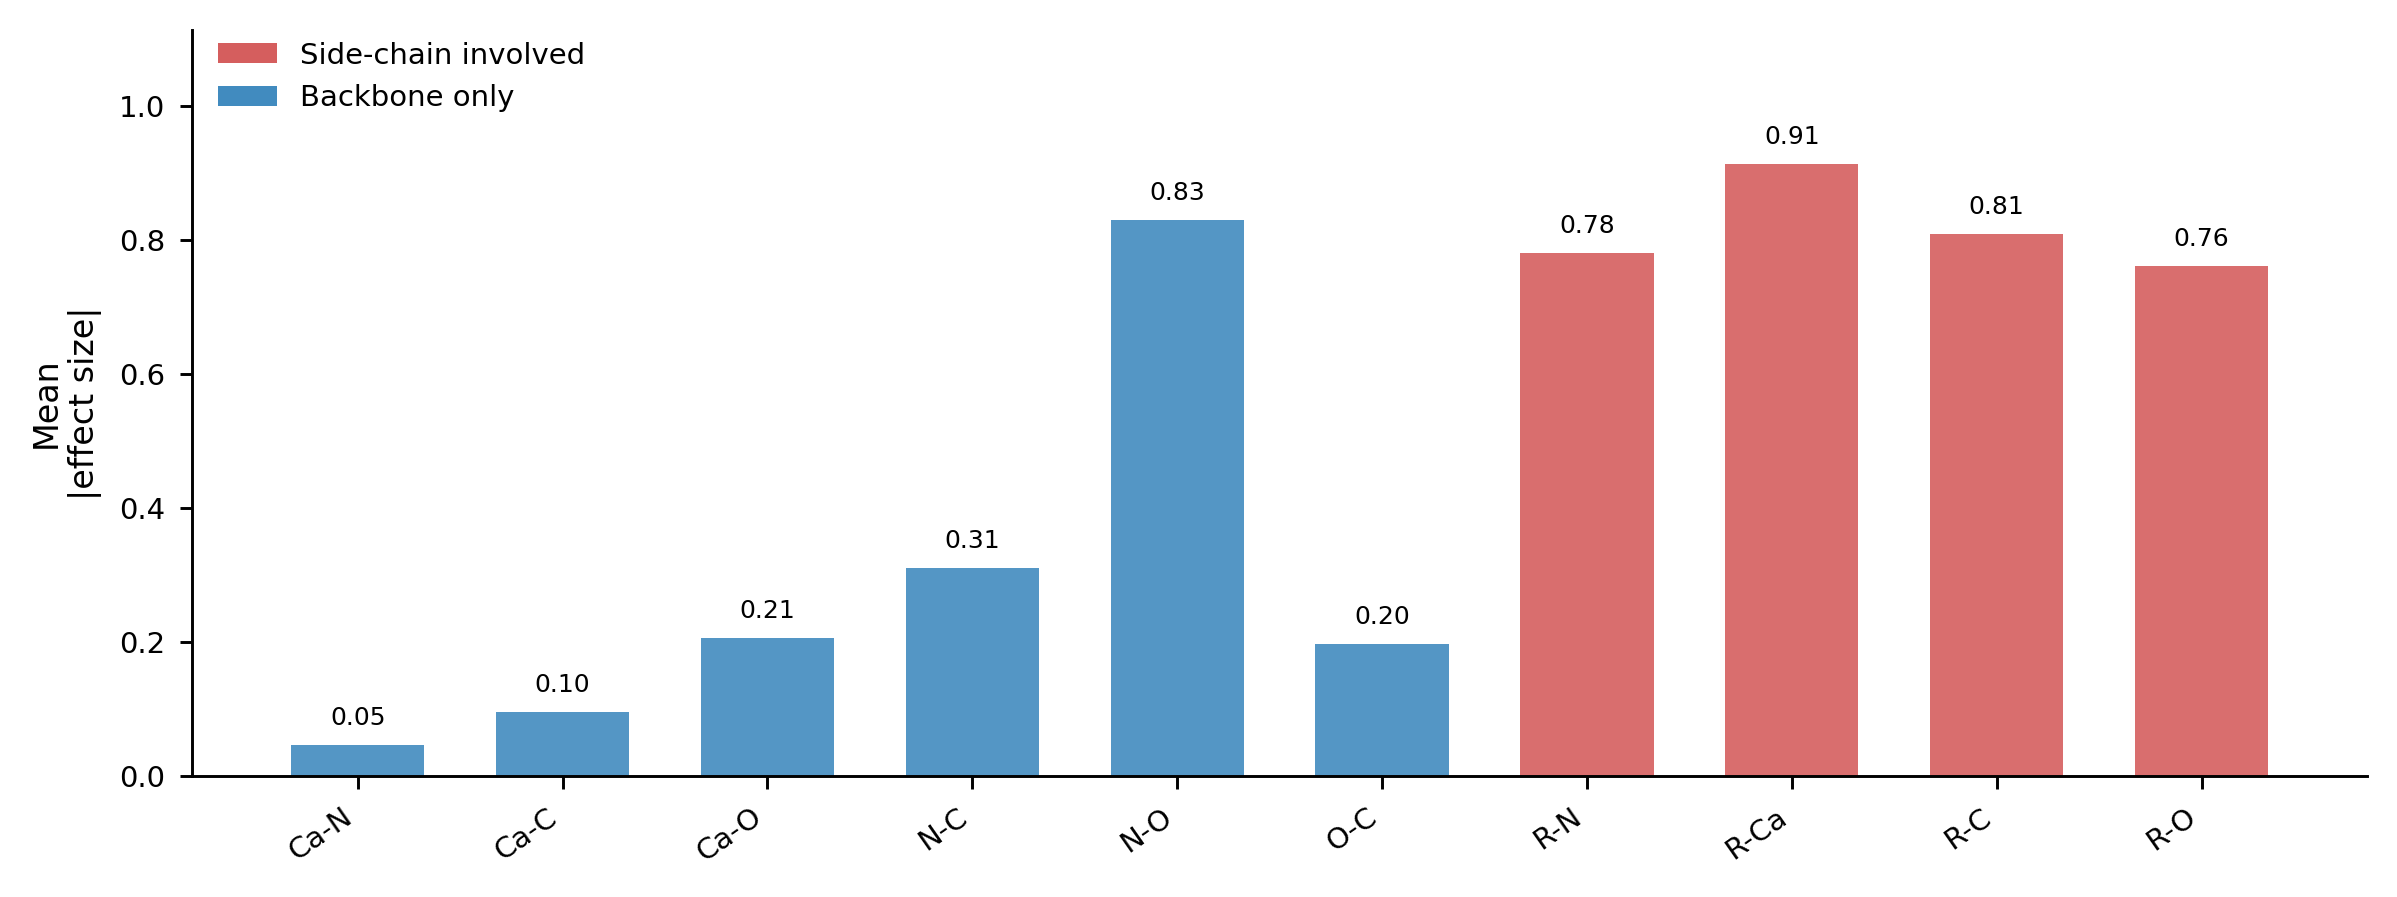

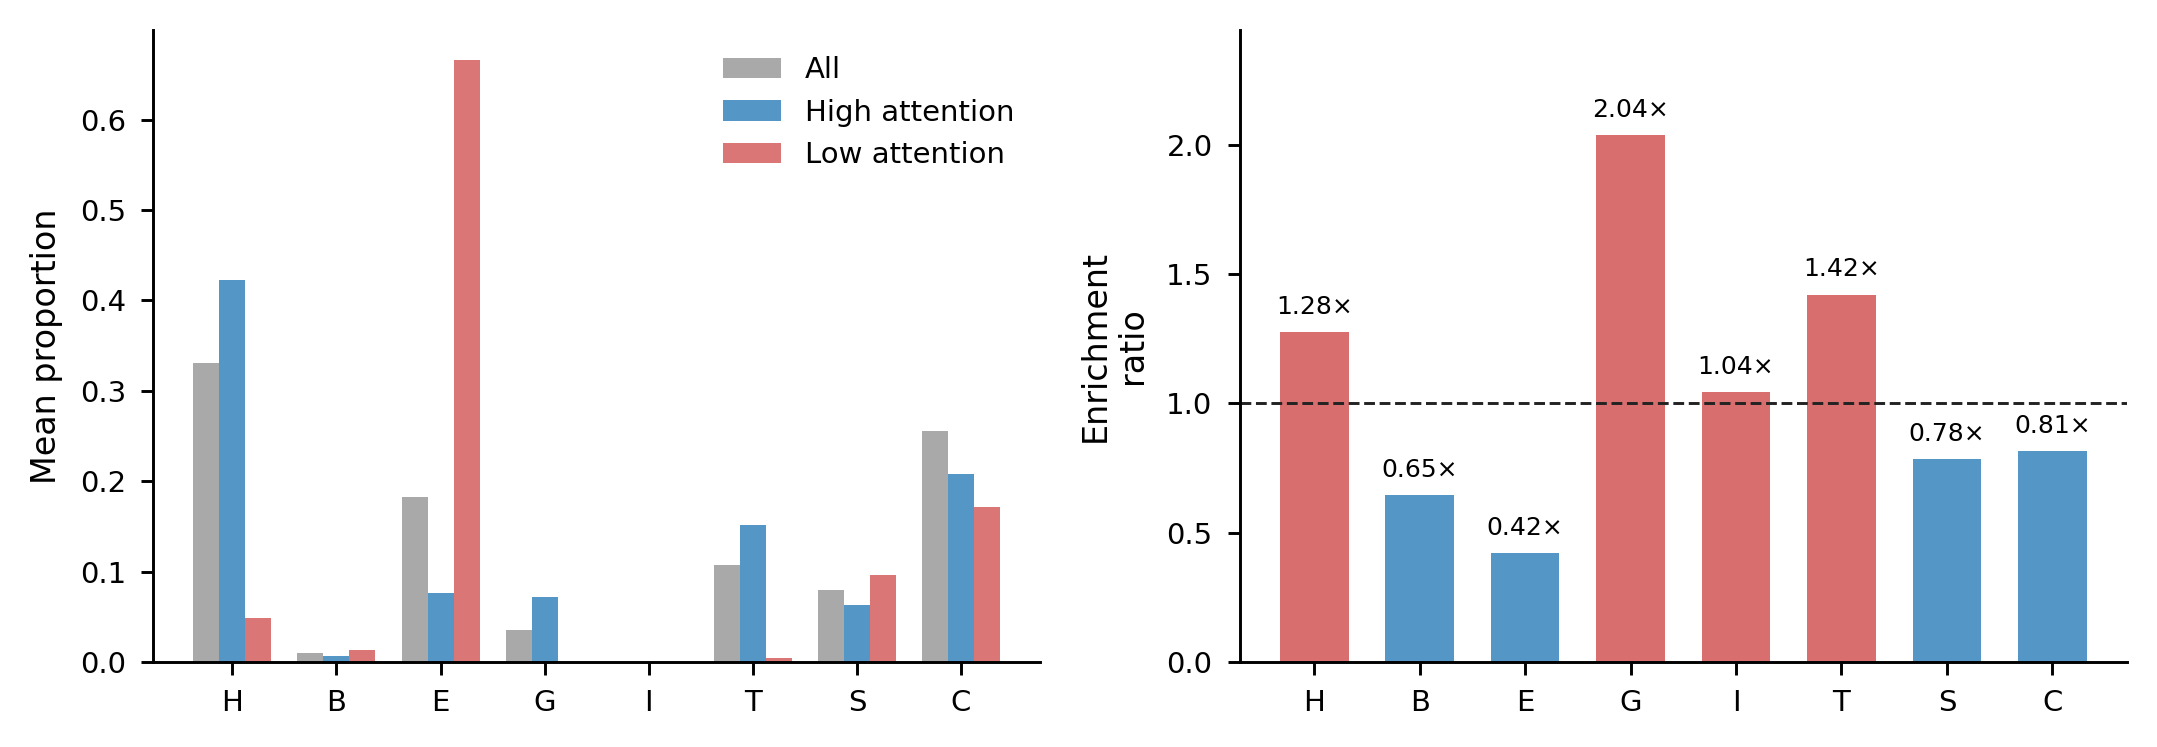

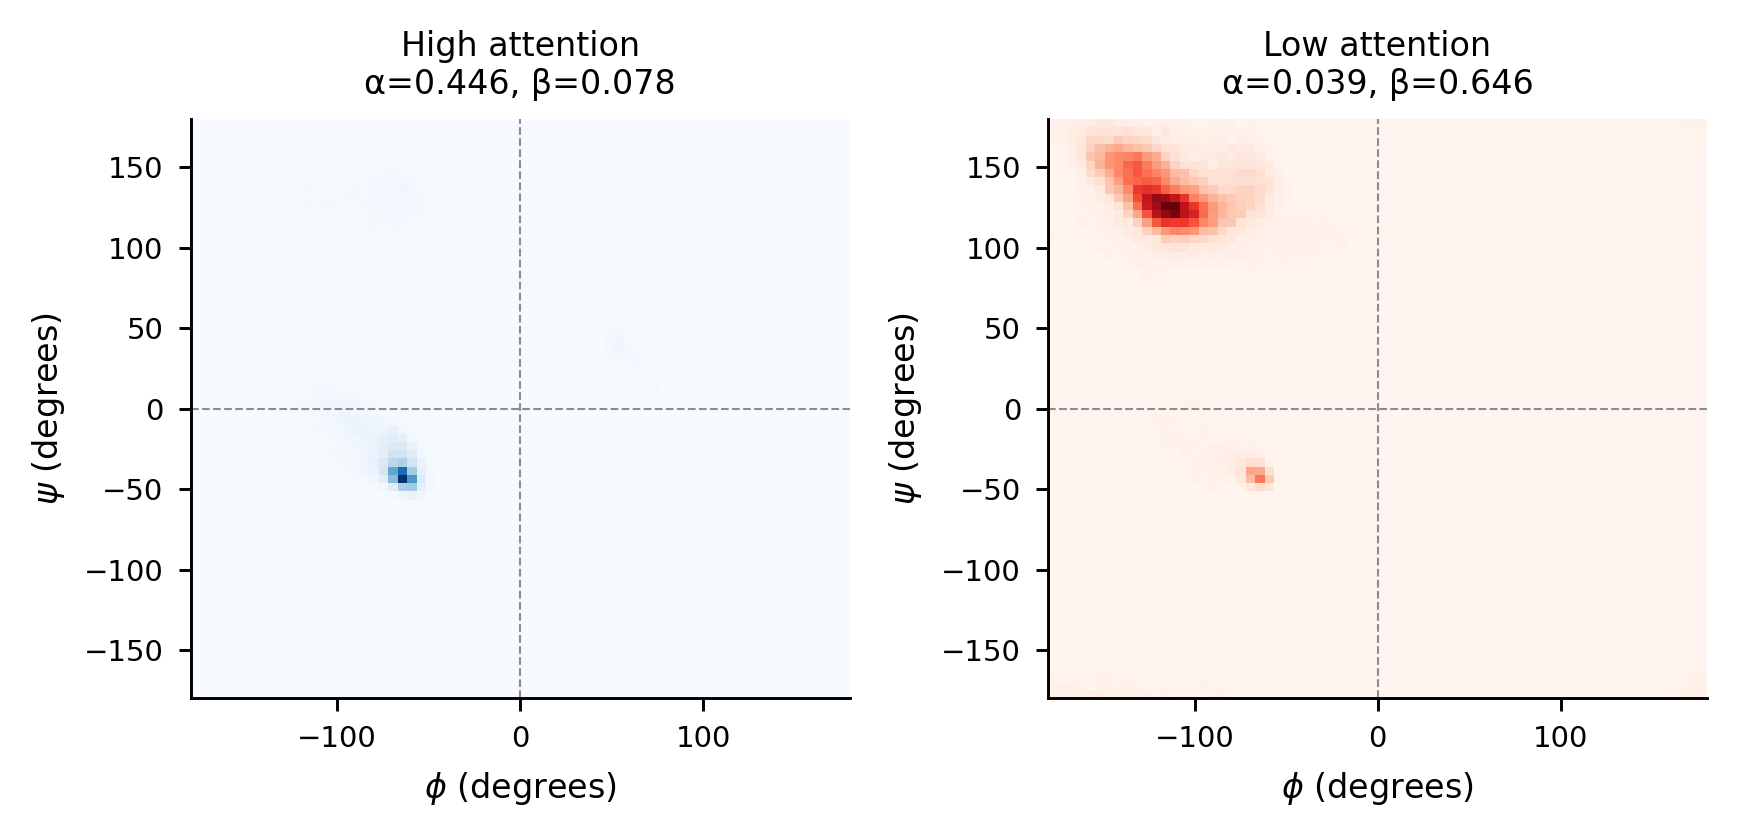

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MultipleLocator
from matplotlib.patches import Patch
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats
from scipy.stats import spearmanr
from tqdm import tqdm
import os, pickle

import egnn_model_split_range
from egnn_model_split_range import DeeppH
egnn_model_split_range.GraphEC_pH = DeeppH
from data_split import ProteinPHValueGraphDataset
from data_split import get_geo_feat
from torch_geometric.loader import DataLoader


plt.rcParams.update({
    "font.size": 7,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

BLUE = '#418BBF'#"#4C78A8"
RED = "#D55E5E"
GREY = "#8C8C8C"
DARK = "#222222"
LIGHT_GREY = "#D9D9D9"

# ============================================================
# Config
# ============================================================
device = "cuda:1"
TOP_PERCENTILE    = 90
BOTTOM_PERCENTILE = 10

ATOM_PAIRS = ['Ca-N', 'Ca-C', 'Ca-O', 'N-C', 'N-O', 'O-C',
              'R-N',  'R-Ca', 'R-C',  'R-O']

SUBCOMP_IDX = {
    'Dihedral (0:6)'     : (0,   6),
    'Bond Angle (6:12)'  : (6,   12),
    'Node Dist (12:172)' : (12,  172),
    'Direction (172:184)': (172, 184),
}
SS_LABELS = ['H', 'B', 'E', 'G', 'I', 'T', 'S', 'C']

def in_alpha(phi, psi):
    return (phi >= -80) & (phi <= -40) & (psi >= -60) & (psi <= -20)

def in_beta(phi, psi):
    return (phi >= -150) & (phi <= -90) & (psi >= 100) & (psi <= 170)

def recover_angle(fgeo, cos_idx, sin_idx):
    return np.arctan2(fgeo[:, sin_idx], fgeo[:, cos_idx]) * 180 / np.pi


print("Extracting f_geo...")
all_fgeo = []
all_fss  = []
all_sasa = []

with torch.no_grad():
    for data_obj in tqdm(test_dataset):
        data_dev    = data_obj.to(device)
        h_V_geo, _  = get_geo_feat(data_dev.X, data_dev.edge_index)
        all_fgeo.append(h_V_geo.cpu().numpy())                          # [L, 184]
        all_sasa.append(data_obj.structure_feat[:, 12].cpu().numpy())      # RSA / SASA
        all_fss.append(data_obj.structure_feat[:, 13:21].cpu().numpy())    # SS one-hot
        # all_fss.append(data_obj.structure_feat[:, 12:20].cpu().numpy()) # [L, 8]
        # all_sasa.append(data_obj.structure_feat[:, 20].cpu().numpy())   # [L]


assert all_fgeo[0].shape[1] == 184, f"Expected 184, got {all_fgeo[0].shape[1]}"
print(f"f_geo dims: {all_fgeo[0].shape[1]} (SASA analyzed separately)")

# ============================================================
# Collect high / low attention residues (per-protein threshold)
# ============================================================
high_att_fgeo = []
low_att_fgeo  = []
high_att_fss  = []
low_att_fss   = []

for fgeo, fss, att_vec in zip(all_fgeo, all_fss, all_protein_att):
    thr_high  = np.percentile(att_vec, TOP_PERCENTILE)
    thr_low   = np.percentile(att_vec, BOTTOM_PERCENTILE)
    high_mask = att_vec >= thr_high
    low_mask  = att_vec <= thr_low
    high_att_fgeo.append(fgeo[high_mask])
    low_att_fgeo.append(fgeo[low_mask])
    high_att_fss.append(fss[high_mask])
    low_att_fss.append(fss[low_mask])

high_att_fgeo = np.vstack(high_att_fgeo)  # [N_high, 184]
low_att_fgeo  = np.vstack(low_att_fgeo)   # [N_low,  184]
high_att_fss  = np.vstack(high_att_fss)
low_att_fss   = np.vstack(low_att_fss)

print(f"High attention residues: {len(high_att_fgeo)}")
print(f"Low  attention residues: {len(low_att_fgeo)}")
def clean_name(name):
    name = re.sub(r"\s*\(.*?\)", "", name)
    name = name.replace("\n", "")
    name = name.replace(" ", "")
    return name.strip()

def style_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3, width=0.7)
    ax.grid(False)

def panel_label(ax, label):
    ax.text(
        -0.18, 1.08, label,
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
        ha="left"
    )

def add_bar_labels(ax, bars, values, fmt="{:.3f}", fontsize=18):
    ymax = max(values)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + ymax * 0.025,
            fmt.format(val),
            ha="center",
            va="bottom",
            fontsize=fontsize
        )

# ============================================================
# Node distance atom-pair effect size
# ============================================================

pair_eff_mad = []
mean_high = high_att_fgeo.mean(axis=0)
mean_low = low_att_fgeo.mean(axis=0)
diff = mean_high - mean_low

pooled_std = np.sqrt(
    (high_att_fgeo.var(axis=0) + low_att_fgeo.var(axis=0)) / 2
)

effect_size = diff / (pooled_std + 1e-8)

dist_effect = effect_size[12:172]
for i, pair in enumerate(ATOM_PAIRS):
    s, e = i * 16, i * 16 + 16
    eff_mad = np.abs(dist_effect[s:e]).mean()
    pair_eff_mad.append(eff_mad)

pair_colors = [RED if "R-" in p else BLUE for p in ATOM_PAIRS]

fig, ax = plt.subplots(figsize=(8, 3), dpi=300)

bars = ax.bar(
    np.arange(len(ATOM_PAIRS)),
    pair_eff_mad,
    color=pair_colors,
    alpha=0.9,
    width=0.65,
    edgecolor="none"
)

ax.set_xticks(np.arange(len(ATOM_PAIRS)))
ax.set_xticklabels(ATOM_PAIRS, rotation=35, ha="right")
ax.set_ylabel("Mean\n|effect size|")
ax.set_ylim(0, max(pair_eff_mad) * 1.22)

add_bar_labels(ax, bars, pair_eff_mad, fmt="{:.2f}", fontsize=6)

legend_elements = [
    Patch(facecolor=RED, label="Side-chain involved"),
    Patch(facecolor=BLUE, label="Backbone only")
]
ax.legend(
    handles=legend_elements,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.0, 1.02)
)

style_ax(ax)
# panel_label(ax, "B")

plt.tight_layout()
# plt.savefig("nature_node_distance_atom_pair_effect.pdf", bbox_inches="tight")
# plt.savefig("nature_node_distance_atom_pair_effect.png", dpi=600, bbox_inches="tight")
plt.show()


# ============================================================
#Secondary-structure enrichment
# ============================================================
def recover_angle(fgeo, cos_idx, sin_idx):
    return np.arctan2(fgeo[:, sin_idx], fgeo[:, cos_idx]) * 180 / np.pi

def in_alpha(phi, psi):
    return (phi >= -80) & (phi <= -40) & (psi >= -60) & (psi <= -20)

def in_beta(phi, psi):
    return (phi >= -150) & (phi <= -90) & (psi >= 100) & (psi <= 170)

phi_high = recover_angle(high_att_fgeo, 0, 3)
psi_high = recover_angle(high_att_fgeo, 1, 4)

phi_low = recover_angle(low_att_fgeo, 0, 3)
psi_low = recover_angle(low_att_fgeo, 1, 4)

alpha_high_frac = in_alpha(phi_high, psi_high).mean()
alpha_low_frac = in_alpha(phi_low, psi_low).mean()

beta_high_frac = in_beta(phi_high, psi_high).mean()
beta_low_frac = in_beta(phi_low, psi_low).mean()
all_fss_flat = np.vstack(all_fss)

base_ss_prop = all_fss_flat.mean(axis=0)
high_ss_prop = high_att_fss.mean(axis=0)
low_ss_prop = low_att_fss.mean(axis=0)

enrichment = np.where(
    base_ss_prop > 0,
    high_ss_prop / base_ss_prop,
    np.nan
)
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.5), dpi=300)

x = np.arange(len(SS_LABELS))
width = 0.25

# A: SS distribution
ax = axes[0]
ax.bar(x - width, base_ss_prop, width, label="All", color=GREY, alpha=0.75, edgecolor="none")
ax.bar(x, high_ss_prop, width, label="High attention", color=BLUE, alpha=0.9, edgecolor="none")
ax.bar(x + width, low_ss_prop, width, label="Low attention", color=RED, alpha=0.85, edgecolor="none")

ax.set_xticks(x)
ax.set_xticklabels(SS_LABELS)
ax.set_ylabel("Mean proportion")
ax.legend(frameon=False, ncol=1, loc="upper right")
style_ax(ax)
# panel_label(ax, "A")

# B: enrichment
ax = axes[1]
colors_ss = [RED if e > 1 else BLUE for e in enrichment]
bars = ax.bar(x, enrichment, color=colors_ss, alpha=0.9, width=0.65, edgecolor="none")
ax.axhline(1.0, color=DARK, lw=0.7, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(SS_LABELS)
ax.set_ylabel("Enrichment\nratio")
ax.set_ylim(0, max(enrichment) * 1.2)

for bar, val in zip(bars, enrichment):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + max(enrichment) * 0.025,
        f"{val:.2f}×",
        ha="center",
        va="bottom",
        fontsize=6
    )

style_ax(ax)
# panel_label(ax, "B")

plt.tight_layout(w_pad=1.3)
# plt.savefig("nature_ss_enrichment.pdf", bbox_inches="tight")
# plt.savefig("nature_ss_enrichment.png", dpi=600, bbox_inches="tight")
plt.show()


# ============================================================
#  Ramachandran high vs low attention
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(5.8, 2.8), dpi=300)

# High attention
ax = axes[0]
h = ax.hist2d(
    phi_high, psi_high,
    bins=70,
    cmap="Blues",
    range=[[-180, 180], [-180, 180]],
    density=True
)
ax.axhline(0, color=GREY, lw=0.5, ls="--")
ax.axvline(0, color=GREY, lw=0.5, ls="--")
ax.set_xlabel("$\\phi$ (degrees)")
ax.set_ylabel("$\\psi$ (degrees)")
ax.set_title(
    f"High attention\nα={alpha_high_frac:.3f}, β={beta_high_frac:.3f}",
    fontsize=8
)
style_ax(ax)
# panel_label(ax, "A")

# Low attention
ax = axes[1]
h = ax.hist2d(
    phi_low, psi_low,
    bins=70,
    cmap="Reds",
    range=[[-180, 180], [-180, 180]],
    density=True
)
ax.axhline(0, color=GREY, lw=0.5, ls="--")
ax.axvline(0, color=GREY, lw=0.5, ls="--")
ax.set_xlabel("$\\phi$ (degrees)")
ax.set_ylabel("$\\psi$ (degrees)")
ax.set_title(
    f"Low attention\nα={alpha_low_frac:.3f}, β={beta_low_frac:.3f}",
    fontsize=8
)
style_ax(ax)
# panel_label(ax, "B")

plt.tight_layout(w_pad=1.3)
# plt.savefig("nature_ramachandran_attention.pdf", bbox_inches="tight")
# plt.savefig("nature_ramachandran_attention.png", dpi=600, bbox_inches="tight")
plt.show()

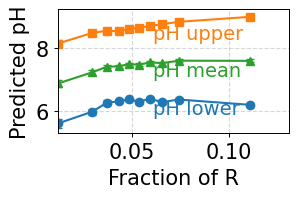

In [25]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

# =========================
# PATH
# =========================
LABEL_PKL = "/home/wang3wa/EC_prediction/mine/deepPH/train/new_test_value.pkl"
PRED_CSV  = "/home/wang3wa/EC_prediction/mine/deepPH/train/model_predictions_all_20250507.csv"

with open(LABEL_PKL, "rb") as f:
    label_data = pickle.load(f)

label_map = {d["id"]: d for d in label_data}


# =========================
df_pred = pd.read_csv(PRED_CSV)


records = []

for _, row in df_pred.iterrows():
    pid = row["id"]
    if pid not in label_map:
        continue

    seq = label_map[pid]["seq"]
    L = len(seq)

    cnt_R = seq.count("R")
    cnt_K = seq.count("K")
    cnt_D = seq.count("D")
    cnt_E = seq.count("E")
    cnt_H = seq.count("H")

    charge_bias = cnt_R / L

    records.append({
        "id": pid,
        "charge_bias": charge_bias,
        "pred_low": row["pred_low"],
        "pred_high": row["pred_high"],
        "pred_mean": (row["pred_high"] + row['pred_low']) / 2,
    })

df = pd.DataFrame(records)


df["bias_bin"] = pd.qcut(df["charge_bias"], q=10)

def compute_stats(df, col):
    grouped = df.groupby("bias_bin")[col]
    x = grouped.mean().index.map(lambda x: x.mid)
    y = grouped.mean()
    yerr = grouped.std() / np.sqrt(grouped.count())
    return x, y, yerr

x_low, y_low, yerr_low     = compute_stats(df, "pred_low")
x_high, y_high, yerr_high  = compute_stats(df, "pred_high")
x_mean, y_mean, yerr_mean  = compute_stats(df, "pred_mean")
x_low = np.array(x_low, dtype=float)
x_high = np.array(x_high, dtype=float)
x_mean = np.array(x_mean, dtype=float)

y_low = np.array(y_low, dtype=float)
y_high = np.array(y_high, dtype=float)
y_mean = np.array(y_mean, dtype=float)
# =========================
# Plot all in one figure with legend outside
# =========================
fig, ax = plt.subplots(figsize=(3, 2))

font_size_ticks  = 15
font_size_labels = 15

ax.errorbar(x_low, y_low, yerr=yerr_low, fmt="o-", capsize=3,
            color="#1f77b4")
ax.errorbar(x_high, y_high, yerr=yerr_high, fmt="s-", capsize=3,
            color="#ff7f0e")
ax.errorbar(x_mean, y_mean, yerr=yerr_mean, fmt="^-", capsize=3,
            color="#2ca02c")

ax.set_xlabel("Fraction of R", fontsize=font_size_labels)
ax.set_ylabel("Predicted pH", fontsize=font_size_labels)

ax.tick_params(axis="x", labelsize=font_size_ticks)
ax.tick_params(axis="y", labelsize=font_size_ticks)
ax.grid(True, linestyle="--", alpha=0.5)


label_idx = len(x_mean) // 2 + 1   
x_shift = 0.002
ax.text(x_high[label_idx] + x_shift, y_high[label_idx] - 0.25, "pH upper",
        color="#ff7f0e", fontsize=14, va="center")

ax.text(x_mean[label_idx] + x_shift, y_mean[label_idx] - 0.25, "pH mean",
        color="#2ca02c", fontsize=14, va="center")

ax.text(x_low[label_idx] + x_shift, y_low[label_idx] - 0.3, "pH lower",
        color="#1f77b4", fontsize=14, va="center")

ax.set_xlim(x_low.min(), x_low.max() + 0.02)

ax.set_xlim(x_low.min(), x_low.max() + 0.02)

plt.tight_layout()

plt.show()


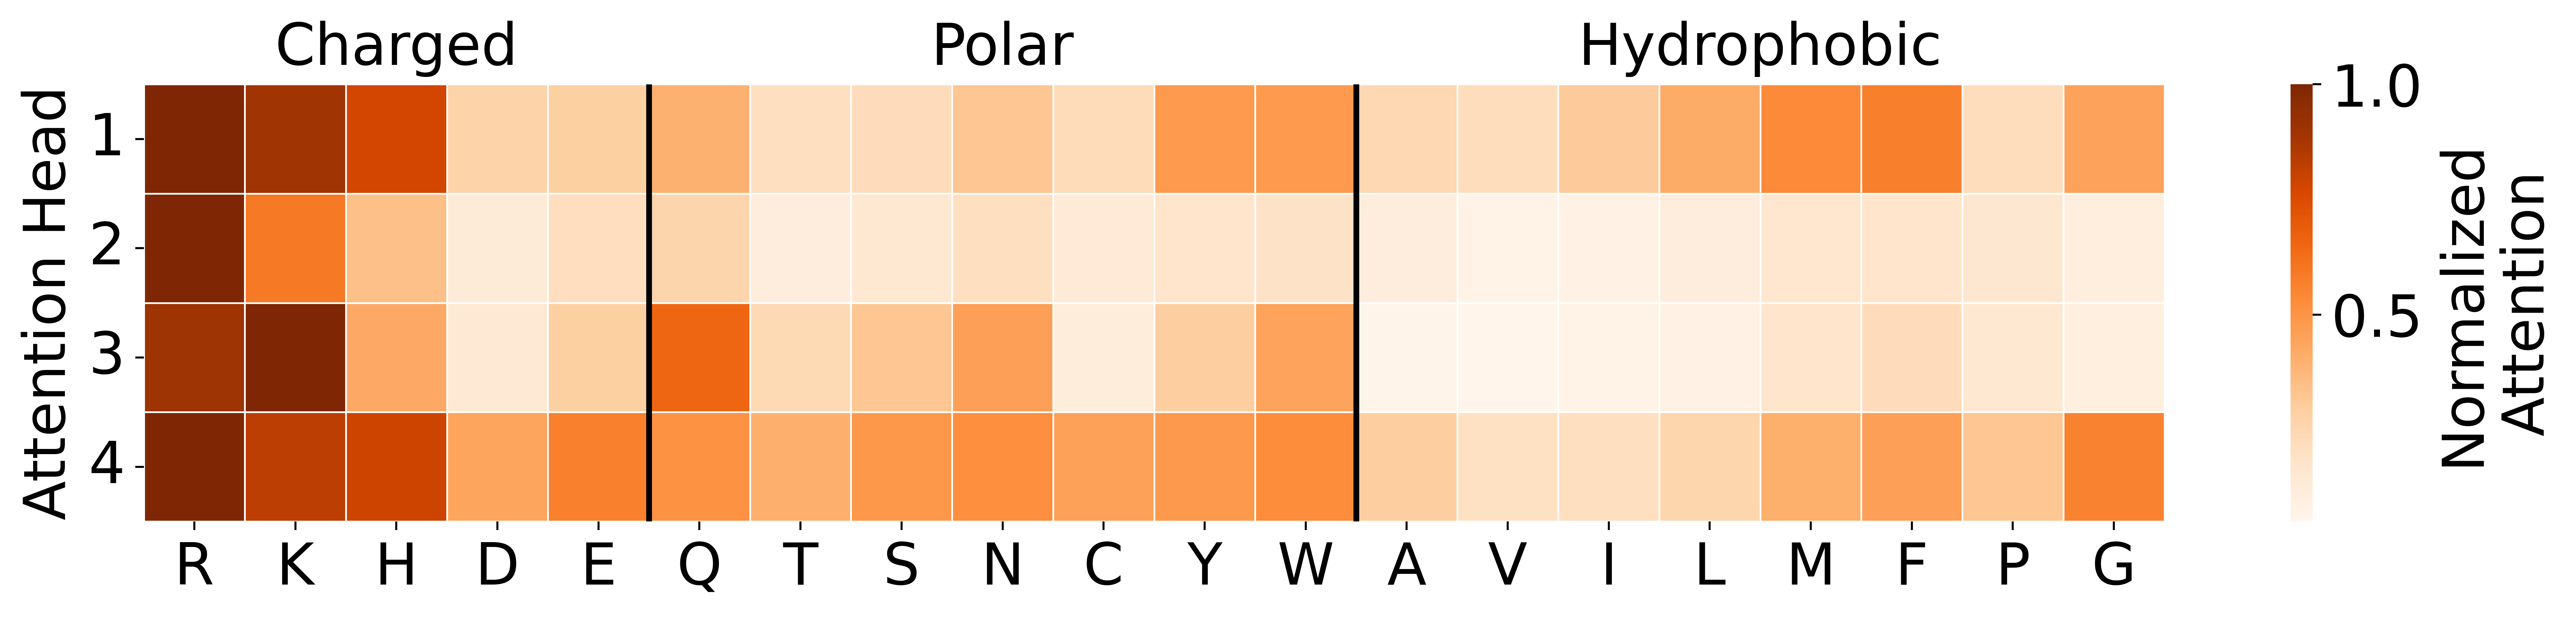

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# =============================
# Font size
# =============================
TITLE_SIZE = 16
LABEL_SIZE = 20
TICK_SIZE = 20
CBAR_SIZE = 18
GROUP_SIZE = 20
# ============================================================
# Amino acid mapping
# ============================================================

idx2aa = {
    0:'A',1:'R',2:'N',3:'D',4:'C',
    5:'Q',6:'E',7:'G',8:'H',9:'I',
    10:'L',11:'K',12:'M',13:'F',14:'P',
    15:'S',16:'T',17:'W',18:'Y',19:'V'
}

AA_ORDER = [
    "R","K","H","D","E",          # Charged
    'Q', 'T', 'S', 'N', 'C', 'Y', 'W',      # Polar
    'A', 'V', 'I', 'L', 'M', 'F', 'P', 'G'   # Hydrophobic
]

aa2col = {aa:i for i,aa in enumerate(AA_ORDER)}

# ============================================================
# statistics
# ============================================================

head_sum = np.zeros((4,20), dtype=np.float64)
head_cnt = np.zeros((4,20), dtype=np.float64)

model.eval()

# ============================================================
# inference
# ============================================================

with torch.no_grad():

    for data in test_dataset:

        data = data.to(device)

        batch = torch.zeros(
            data.num_nodes,
            dtype=torch.long,
            device=device
        )

        _, all_attention_weights = model(
            data.X,
            data.structure_feat,
            data.seq_feat,
            data.edge_index,
            batch
        )

        # only one protein
        att = all_attention_weights[0]

        # shape: (1,4,L)
        att = att.squeeze(0).cpu().numpy()

        seq = data.seq.cpu().numpy()

        for head in range(4):

            for aa_idx, w in zip(seq, att[head]):

                aa = idx2aa[int(aa_idx)]

                col = aa2col[aa]

                head_sum[head, col] += float(w)
                head_cnt[head, col] += 1

# ============================================================
# Mean attention
# ============================================================

heat = head_sum / np.maximum(head_cnt, 1)

# Normalize each head independently
heat = heat / heat.max(axis=1, keepdims=True)

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(13, 3), dpi=600)

hm = sns.heatmap(
    heat,
    cmap="Oranges",
    linewidths=0.6,
    linecolor="white",
    xticklabels=AA_ORDER,
    yticklabels=["1", "2", "3", "4"],
    cbar_kws={"label": "Normalized Attention"},
    ax=ax
)

# =============================
# Colorbar
# =============================
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=TICK_SIZE)
cbar.set_label("Normalized\nAttention", fontsize=LABEL_SIZE)

# =============================
# Group separators
# =============================
ax.vlines(
    [5, 12],
    *ax.get_ylim(),
    colors="black",
    linewidth=2
)

# =============================
# Group labels
# =============================
ax.text(
    2.5, -0.18,
    "Charged",
    ha="center",
    fontsize=GROUP_SIZE,
    # fontweight="bold"
)

ax.text(
    8.5, -0.18,
    "Polar",
    ha="center",
    fontsize=GROUP_SIZE,
    # fontweight="bold"
)

ax.text(
    16, -0.18,
    "Hydrophobic",
    ha="center",
    fontsize=GROUP_SIZE,
    # fontweight="bold"
)

# =============================
# Axis
# =============================
ax.tick_params(axis='x', labelrotation=0, labelsize=TICK_SIZE)
ax.tick_params(axis='y', labelrotation=0, labelsize=TICK_SIZE)

ax.set_xlabel("")
ax.set_ylabel("Attention Head", fontsize=LABEL_SIZE)

plt.tight_layout()
plt.show()

In [35]:
protein_ids = [item.get("id", f"p{i}") for i, item in enumerate(all_data)]
sequences = [item.get("seq", "") for item in all_data]

print(f"Total proteins: {len(protein_ids)}")
CACHE_PATH    = "/home/wang3wa/EC_prediction/mine/JBHI/result/uniprot_cache.pkl"
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "rb") as f:
        uniprot_cache = pickle.load(f)
    print(f"Loaded cache: {len(uniprot_cache)} proteins already queried")
else:
    uniprot_cache = {}

def save_cache():
    with open(CACHE_PATH, "wb") as f:
        pickle.dump(uniprot_cache, f)

# ------------------------------------------------------------
# Step 1: UniProt query function (with caching)
# ------------------------------------------------------------
def fetch_uniprot_features(uniprot_id):
    if uniprot_id in uniprot_cache:
        return uniprot_cache[uniprot_id]

    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.json"
    functional_residues = {}
    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code == 200:
            data = resp.json()
            for feat in data.get('features', []):
                ftype = feat.get('type', '')
                if ftype in RELEVANT_TYPES:
                    loc = feat.get('location', {})
                    start = loc.get('start', {}).get('value')
                    end   = loc.get('end',   {}).get('value')
                    if start is not None:
                        end = end if end is not None else start
                        for pos in range(start, end + 1):
                            functional_residues[pos] = ftype
    except Exception as e:
        print(f"  [{uniprot_id}] request failed: {e}")

    uniprot_cache[uniprot_id] = functional_residues
    return functional_residues
active_site_att = []
non_active_site_att = []

for i, pid in enumerate(protein_ids):
    func_sites = uniprot_cache.get(pid, {})
    active_positions = [p for p, t in func_sites.items() if t == 'Active site']
    if not active_positions:
        continue
    att_vec = all_protein_att[i]
    L = len(att_vec)
    active_idx0 = np.array([p-1 for p in active_positions if 1 <= p <= L])
    non_active_idx0 = np.setdiff1d(np.arange(L), active_idx0)
    
    # Normalize per protein
    att_norm = att_vec / att_vec.mean()
    
    active_site_att.extend(att_norm[active_idx0])
    non_active_site_att.extend(att_norm[non_active_idx0])

active_site_att = np.array(active_site_att)
non_active_site_att = np.array(non_active_site_att)

print(f"Active site residues (n={len(active_site_att)}): mean={active_site_att.mean():.3f}")
print(f"Non-active site residues (n={len(non_active_site_att)}): mean={non_active_site_att.mean():.3f}")

from scipy import stats
u_stat, p_val = stats.mannwhitneyu(active_site_att, non_active_site_att, alternative='greater')
print(f"Mann-Whitney U (Active > Non-active): p={p_val:.2e}")

Total proteins: 803
Loaded cache: 803 proteins already queried
Active site residues (n=279): mean=1.167
Non-active site residues (n=94642): mean=1.000
Mann-Whitney U (Active > Non-active): p=2.39e-09


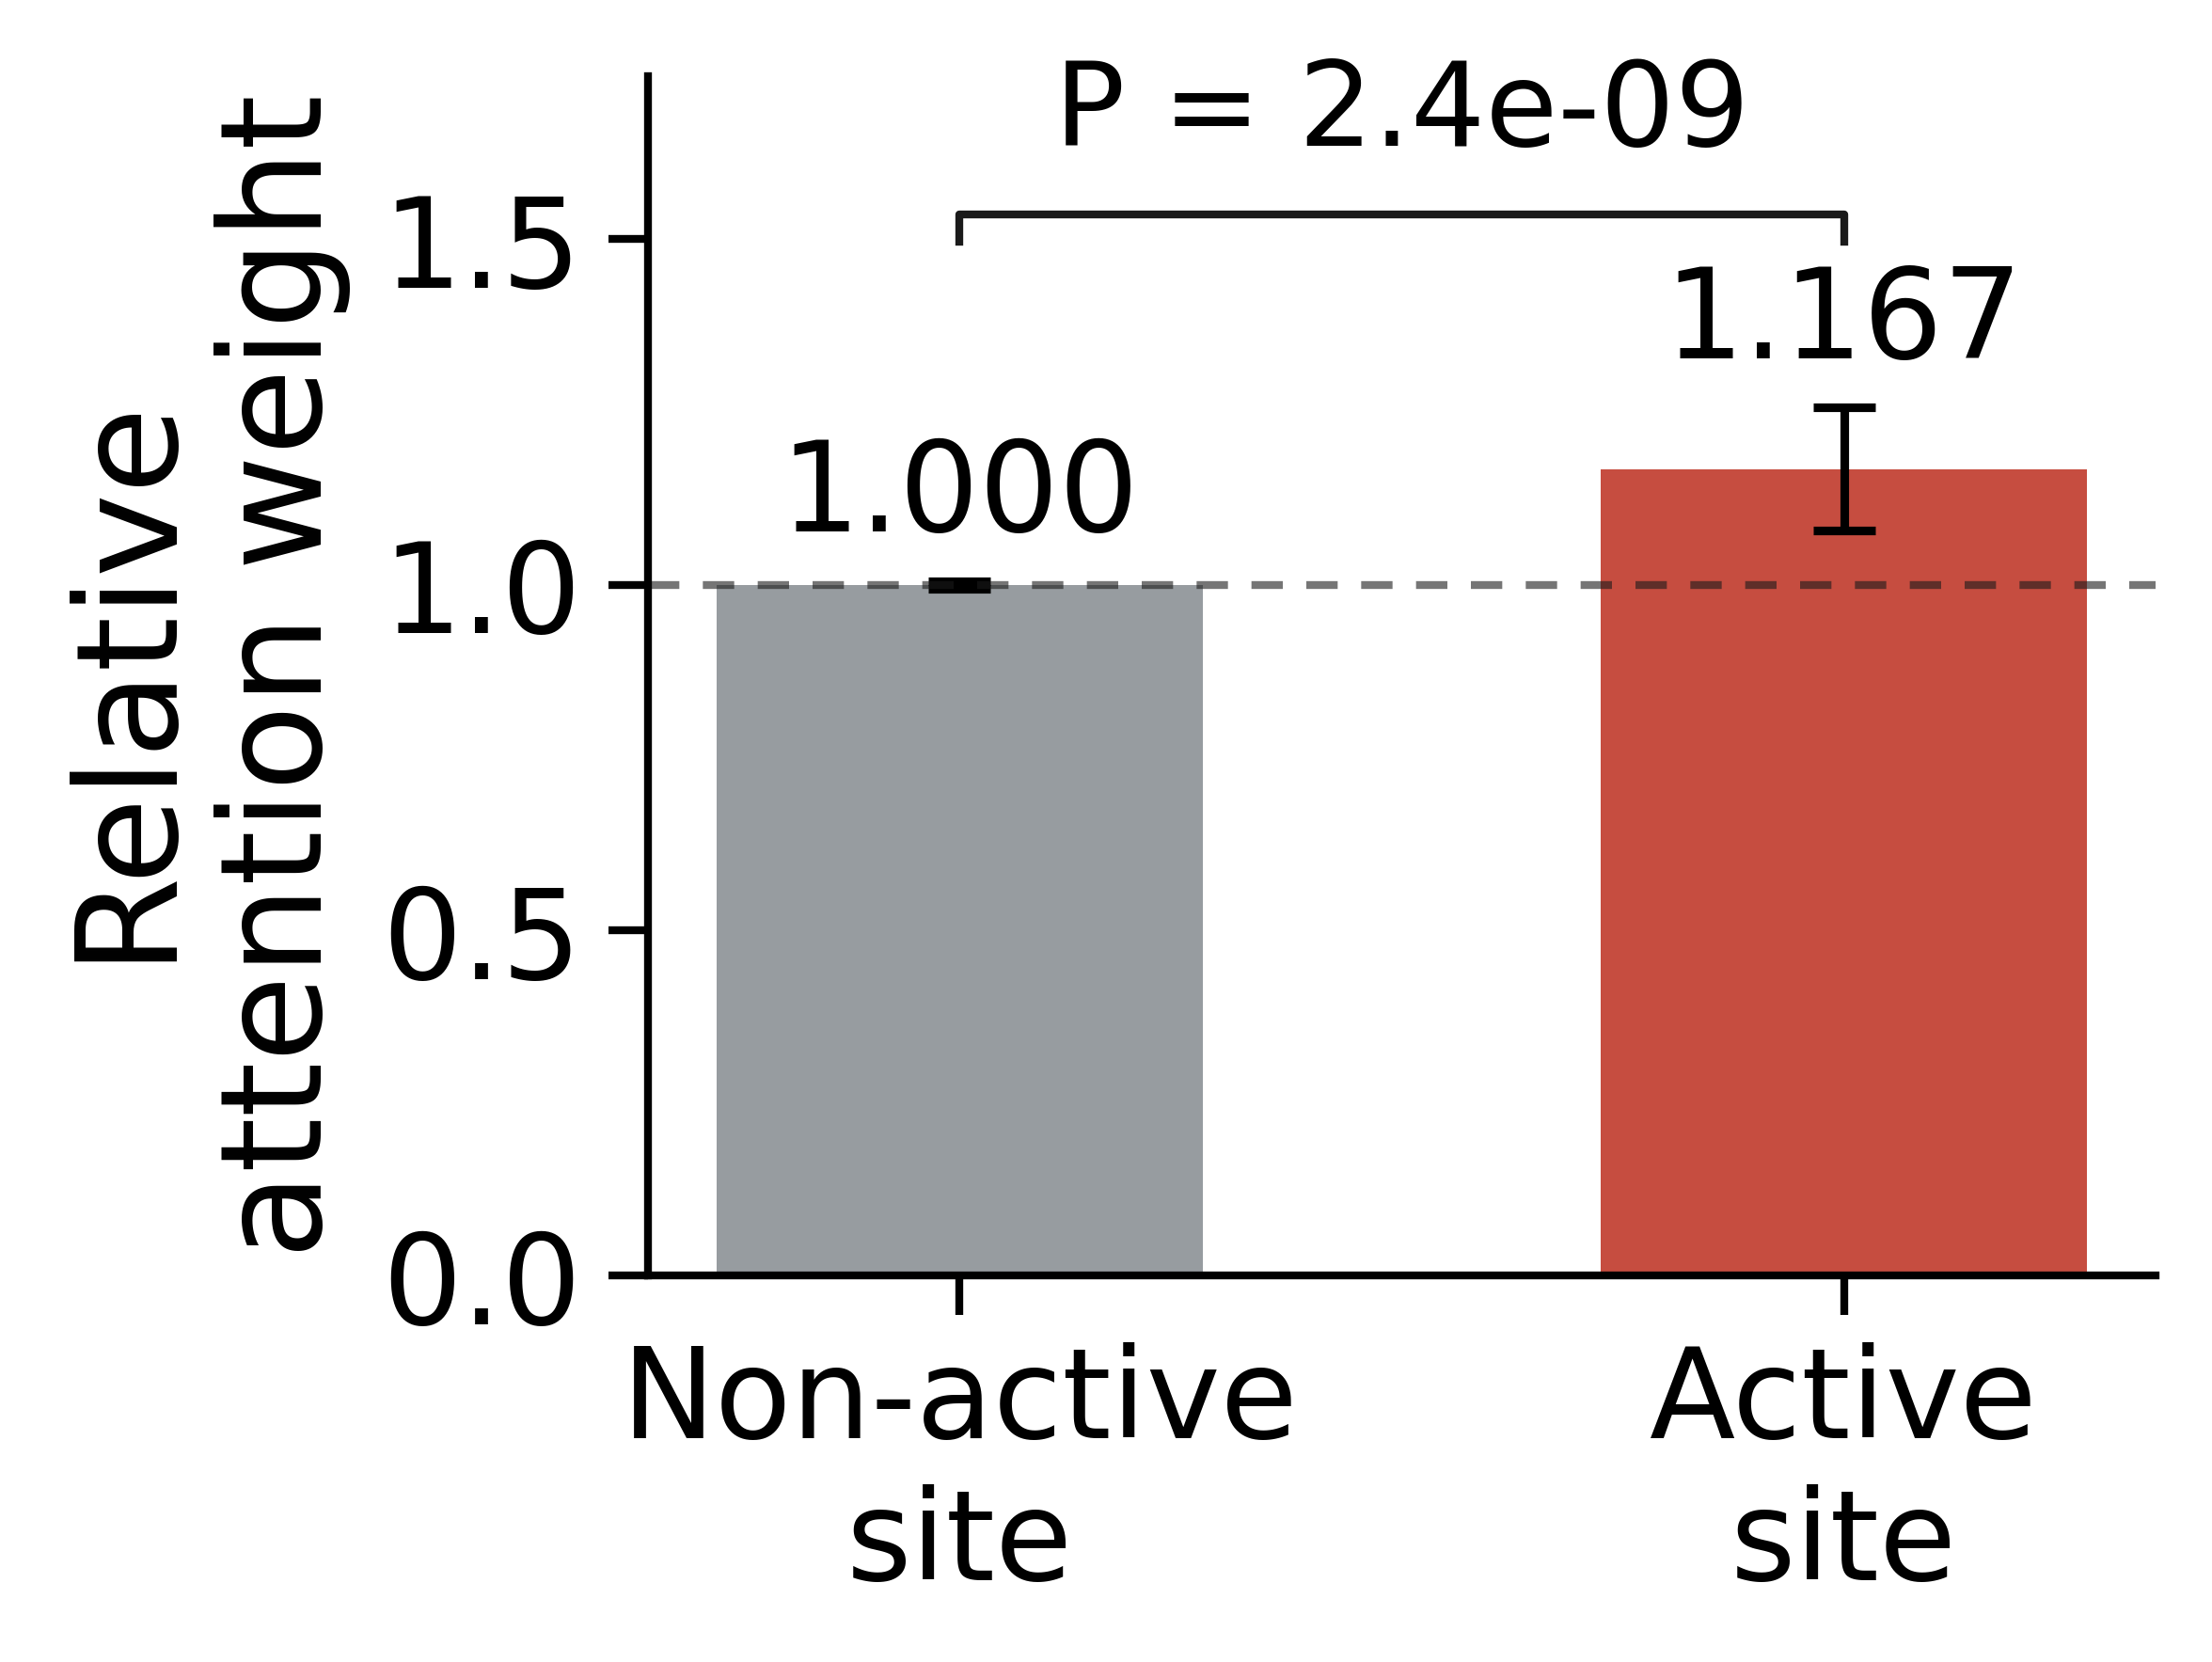

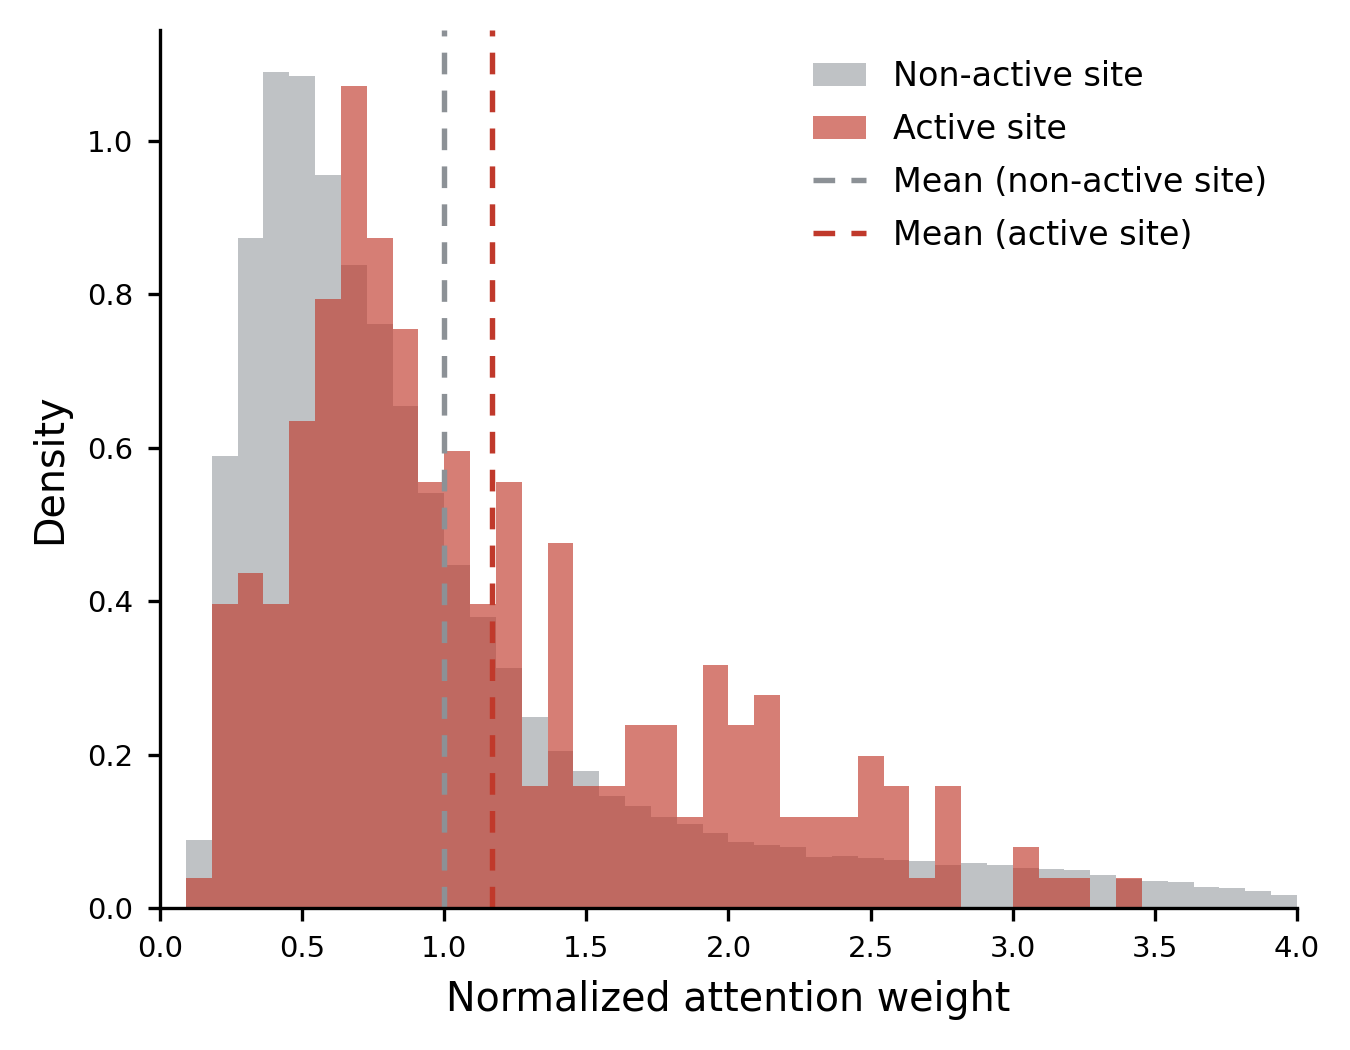

In [36]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy import stats

# ----------------------------
# Font size
# ----------------------------
LABEL_SIZE  = 18
TICK_SIZE   = 16
VALUE_SIZE  = 16
PVALUE_SIZE = 15

# ----------------------------
# Style
# ----------------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    # "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": TICK_SIZE,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

COLOR_NON_ACTIVE = "#8C9196"
COLOR_ACTIVE     = "#C0392B"
COLOR_LINE       = "#1A1A1A"

# ----------------------------
# Data
# ----------------------------
means = [
    non_active_site_att.mean(),
    active_site_att.mean()
]

sems = [
    stats.sem(non_active_site_att) * 1.96,
    stats.sem(active_site_att) * 1.96
]

colors = [COLOR_NON_ACTIVE, COLOR_ACTIVE]
x_pos = np.array([0, 1])

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(4.2, 3.2), dpi=600)

bars = ax.bar(
    x_pos,
    means,
    yerr=sems,
    color=colors,
    alpha=0.9,
    width=0.55,
    capsize=4,
    error_kw={
        "elinewidth": 1.1,
        "capthick": 1.1
    }
)

# Baseline
ax.axhline(
    1.0,
    color=COLOR_LINE,
    linestyle=(0, (4, 3)),
    linewidth=1.0,
    alpha=0.6
)

# Axis labels
ax.set_xticks(x_pos)
ax.set_xticklabels(
    ["Non-active\nsite", "Active\nsite"],
    fontsize=TICK_SIZE
)


ax.set_ylabel("Relative\nattention weight", fontsize=LABEL_SIZE)
ax.tick_params(
    axis="both",
    labelsize=TICK_SIZE,
    width=1.0,
    length=5
)

# Value labels
for x, val, sem in zip(x_pos, means, sems):
    ax.text(
        x,
        val + sem + 0.035,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=VALUE_SIZE
    )

# P-value bracket
y_top = max([m + s for m, s in zip(means, sems)])
y_brack = y_top + 0.28

ax.plot(
    [0, 0, 1, 1],
    [y_brack - 0.04, y_brack, y_brack, y_brack - 0.04],
    color=COLOR_LINE,
    linewidth=1.0
)

ax.text(
    0.5,
    y_brack + 0.065,
    f"P = {p_val:.1e}",
    ha="center",
    va="bottom",
    fontsize=PVALUE_SIZE
)

ax.set_ylim(0, y_brack + 0.20)

# Clean frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'svg.fonttype': 'none',
})

COLOR_NON_ACTIVE = '#8C9196'
COLOR_ACTIVE     = '#C0392B'

# ------------------------------------------------------------
# Figure 2: Distribution comparison (legend explains dashed lines)
# ------------------------------------------------------------
fig2, ax = plt.subplots(figsize=(4.6, 3.6), dpi=300)
bins = np.linspace(0, 4, 45)

ax.hist(non_active_site_att, bins=bins, density=True, alpha=0.55,
        color=COLOR_NON_ACTIVE, linewidth=0)
ax.hist(active_site_att, bins=bins, density=True, alpha=0.65,
        color=COLOR_ACTIVE, linewidth=0)

mean_na = non_active_site_att.mean()
mean_a  = active_site_att.mean()

ax.axvline(mean_na, color=COLOR_NON_ACTIVE, linestyle=(0, (4, 3)), linewidth=1.3)
ax.axvline(mean_a,  color=COLOR_ACTIVE, linestyle=(0, (4, 3)), linewidth=1.3)

ax.set_xlabel('Normalized attention weight', fontsize=9.5)
ax.set_ylabel('Density', fontsize=9.5)
ax.set_xlim(0, 4)

# Custom legend: solid patches for histograms, dashed lines for means
legend_elements = [
    Patch(facecolor=COLOR_NON_ACTIVE, alpha=0.55, label='Non-active site'),
    Patch(facecolor=COLOR_ACTIVE, alpha=0.65, label='Active site'),
    Line2D([0], [0], color=COLOR_NON_ACTIVE, linestyle=(0, (4, 3)), linewidth=1.3,
           label='Mean (non-active site)'),
    Line2D([0], [0], color=COLOR_ACTIVE, linestyle=(0, (4, 3)), linewidth=1.3,
           label='Mean (active site)'),
]
ax.legend(handles=legend_elements, fontsize=8, frameon=False,
          loc='upper right', handlelength=1.6, labelspacing=0.6)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()


P61711 active sites: [86]
Q55650 active sites: [124, 194, 198]


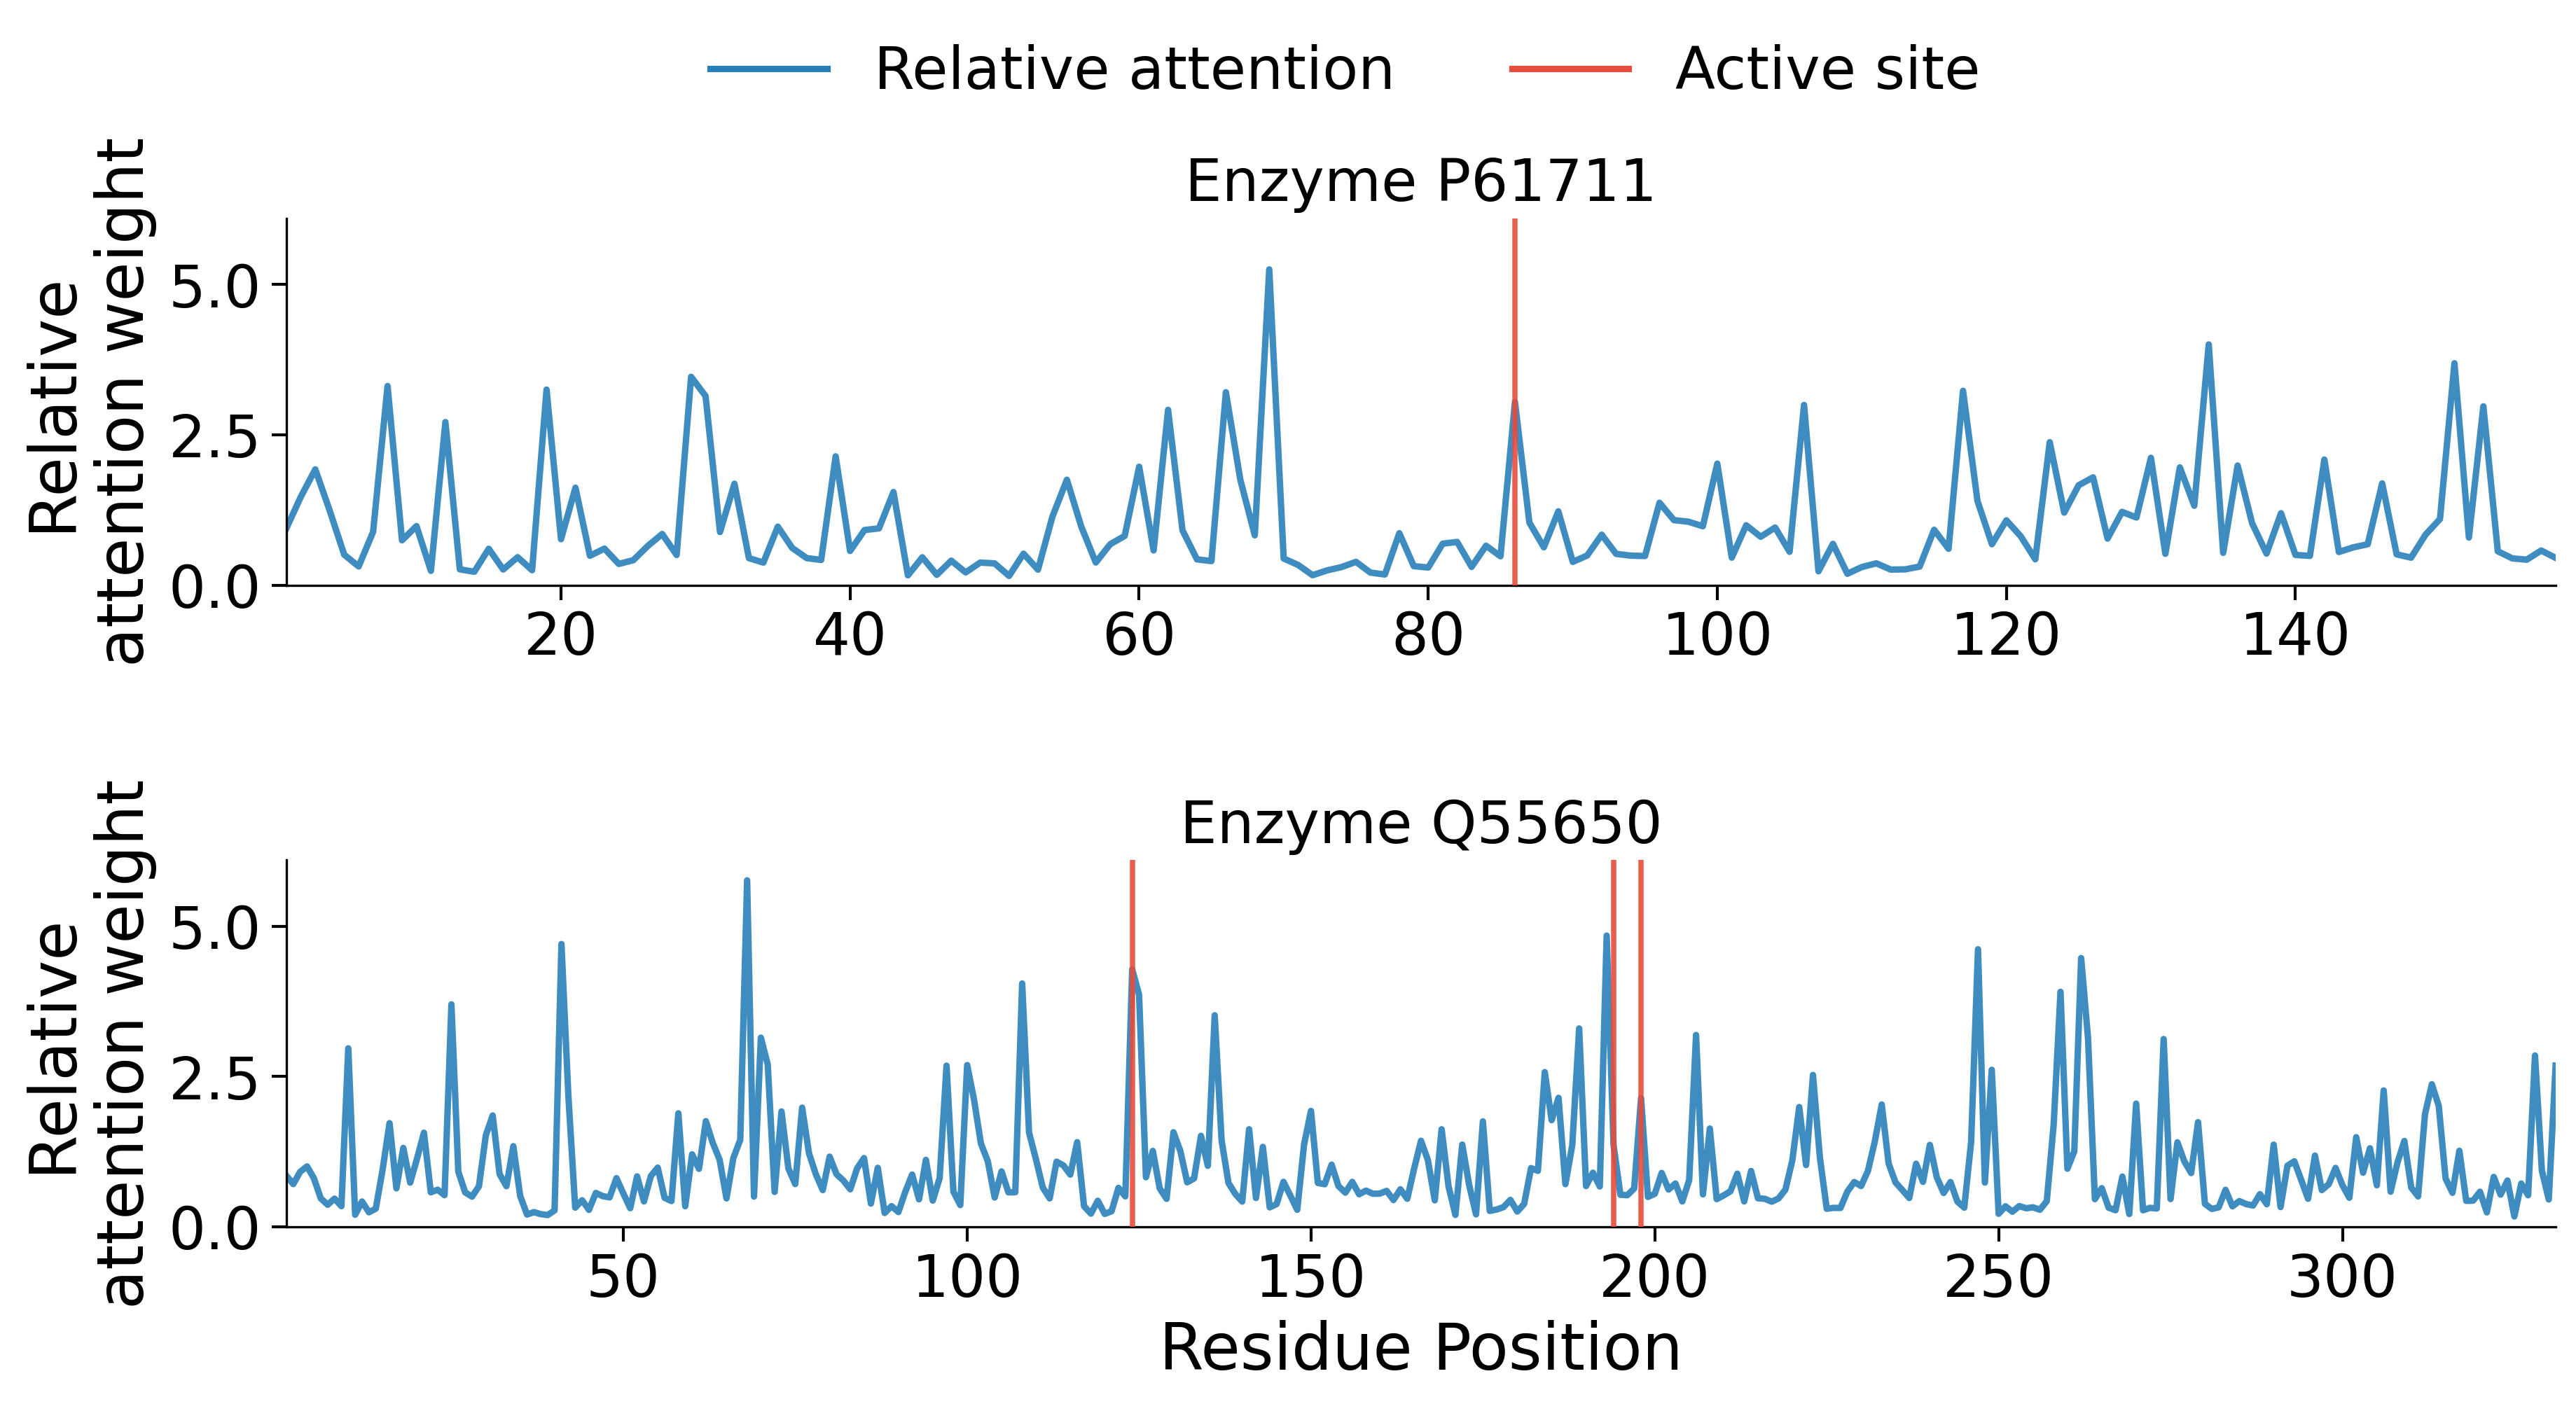

In [37]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

FINAL_VIZ_IDS = ['P61711', 'Q55650']

# ---- Font size controls ----
FONT_TITLE  = 20
FONT_LABEL  = 22
FONT_TICK   = 20
FONT_LEGEND = 20

n_proteins = len(FINAL_VIZ_IDS)
fig, axes = plt.subplots(n_proteins, 1, figsize=(12, 3.0 * n_proteins), dpi=300)

if n_proteins == 1:
    axes = [axes]

all_curves = []
all_meta = []

for pid in FINAL_VIZ_IDS:
    idx = protein_ids.index(pid)
    att_vec = all_protein_att[idx]

    # Relative attention: 1 means protein-level average
    att_rel = att_vec / att_vec.mean()

    L = len(att_rel)

    func_sites = uniprot_cache.get(pid, {})
    active_positions = sorted([p for p, t in func_sites.items() if t == 'Active site'])
    active_idx0 = [p - 1 for p in active_positions if 1 <= p <= L]

    all_curves.append(att_rel)
    all_meta.append({
        'pid': pid,
        'L': L,
        'active_positions': active_positions,
        'active_idx0': active_idx0,
    })

y_max = max(curve.max() for curve in all_curves)
y_upper = np.ceil(y_max * 1.05 * 10) / 10
y_lower = 0

for meta in all_meta:
    print(meta["pid"], "active sites:", meta["active_positions"])

for ax, att_rel, meta in zip(axes, all_curves, all_meta):
    pid = meta['pid']
    L = meta['L']
    active_positions = meta['active_positions']
    active_idx0 = meta['active_idx0']

    residue_positions = np.arange(1, L + 1)

    ax.plot(
        residue_positions,
        att_rel,
        color='#2980B9',
        linewidth=2.2,
        alpha=0.9
    )

    for pos in active_positions:
        ax.axvline(
            pos,
            color='#E74C3C',
            linewidth=1.8,
            alpha=0.9,
            zorder=5
        )

    mean_att_active = att_rel[active_idx0].mean() if active_idx0 else np.nan

    ax.set_xlim(1, L)
    ax.set_ylim(y_lower, y_upper)

    if ax is axes[-1]:
        ax.set_xlabel("Residue Position", fontsize=FONT_LABEL)
    else:
        ax.set_xlabel("")
    # ax.set_ylabel('Relative\nattention', fontsize=FONT_LABEL)
    ax.set_ylabel("Relative\nattention weight", fontsize=FONT_LABEL)
    ax.set_title(
        f'Enzyme {pid}',
        #   (L={L}, active sites={len(active_idx0)}, 
        # f'active-site attention={mean_att_active:.2f}×)',
        fontsize=FONT_TITLE
    )

    ax.tick_params(axis='both', labelsize=FONT_TICK, width=1.0, length=5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_elements = [
    Line2D([0], [0], color='#2980B9', lw=2.2, label='Relative attention'),
    Line2D([0], [0], color='#E74C3C', lw=2.2, label='Active site'),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.06),    
    ncol=2,
    fontsize=FONT_LEGEND,
    frameon=False
)

plt.subplots_adjust(
    top=0.88,
    bottom=0.08,
    left=0.08,
    right=0.98,
    hspace=0.75
)


plt.show()